# Activation Functions

## Objectives
- Understand ReLU, Sigmoid, Tanh, GELU, Swish, ELU
- Learn about vanishing and exploding gradients
- Visualize activation functions and their derivatives
- Compare activations in practice
- Choose activation functions for different scenarios

## Introduction
Activation functions introduce non-linearity to neural networks, enabling them to learn complex patterns. This notebook covers the most important activation functions and their properties.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [4]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# Iterate through batches of data
# Create x axis for visualization
x = np.linspace(-5, 5, 1000)
x_torch = torch.tensor(x, dtype=torch.float32)
x_torch.requires_grad = True


In [5]:
# Execute code with detailed step-by-step process
## 1. ReLU (Rectified Linear Unit)

relu = nn.ReLU()
y_relu = relu(x_torch).detach().numpy()

# Compute gradient
x_torch.grad = None
y = relu(x_torch).sum()
y.backward()
grad_relu = x_torch.grad.numpy()

print("ReLU: max(0, x)")
print(f"Output range: [{y_relu.min():.2f}, {y_relu.max():.2f}]")
print(f"Gradient at x=-1: {grad_relu[np.argmin(np.abs(x-(-1)))]}")
print(f"Gradient at x=1: {grad_relu[np.argmin(np.abs(x-1))]}")


ReLU: max(0, x)
Output range: [0.00, 5.00]
Gradient at x=-1: 0.0
Gradient at x=1: 1.0


In [6]:
# Execute code with detailed step-by-step process
## 2. Sigmoid and Tanh

sigmoid = nn.Sigmoid()
tanh = nn.Tanh()

y_sigmoid = sigmoid(x_torch).detach().numpy()
y_tanh = tanh(x_torch).detach().numpy()

# Compute gradients
x_torch.grad = None
y = sigmoid(x_torch).sum()
y.backward()
grad_sigmoid = x_torch.grad.numpy()

x_torch.grad = None
y = tanh(x_torch).sum()
y.backward()
grad_tanh = x_torch.grad.numpy()

print("Sigmoid: 1/(1+exp(-x))")
print(f"Output range: [{y_sigmoid.min():.2f}, {y_sigmoid.max():.2f}]")
print(f"Max gradient: {grad_sigmoid.max():.4f}")

print("\nTanh: (exp(x)-exp(-x))/(exp(x)+exp(-x))")
print(f"Output range: [{y_tanh.min():.2f}, {y_tanh.max():.2f}]")
print(f"Max gradient: {grad_tanh.max():.4f}")


Sigmoid: 1/(1+exp(-x))
Output range: [0.01, 0.99]
Max gradient: 0.2500

Tanh: (exp(x)-exp(-x))/(exp(x)+exp(-x))
Output range: [-1.00, 1.00]
Max gradient: 1.0000


In [7]:
# Execute code with detailed step-by-step process
## 3. GELU (Gaussian Error Linear Unit)

gelu = nn.GELU()
y_gelu = gelu(x_torch).detach().numpy()

x_torch.grad = None
y = gelu(x_torch).sum()
y.backward()
grad_gelu = x_torch.grad.numpy()

print("GELU: x * P(X <= x) where P is Gaussian CDF")
print(f"Output range: [{y_gelu.min():.2f}, {y_gelu.max():.2f}]")


GELU: x * P(X <= x) where P is Gaussian CDF
Output range: [-0.17, 5.00]


In [8]:
# Execute code with detailed step-by-step process
## 4. Swish and ELU

swish = nn.SiLU()  # Swish is also known as SiLU
elu = nn.ELU(alpha=1.0)

y_swish = swish(x_torch).detach().numpy()
y_elu = elu(x_torch).detach().numpy()

x_torch.grad = None
y = swish(x_torch).sum()
y.backward()
grad_swish = x_torch.grad.numpy()

x_torch.grad = None
y = elu(x_torch).sum()
y.backward()
grad_elu = x_torch.grad.numpy()

print("Swish: x * sigmoid(x)")
print("ELU: x if x > 0 else alpha*(exp(x)-1)")


Swish: x * sigmoid(x)
ELU: x if x > 0 else alpha*(exp(x)-1)


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


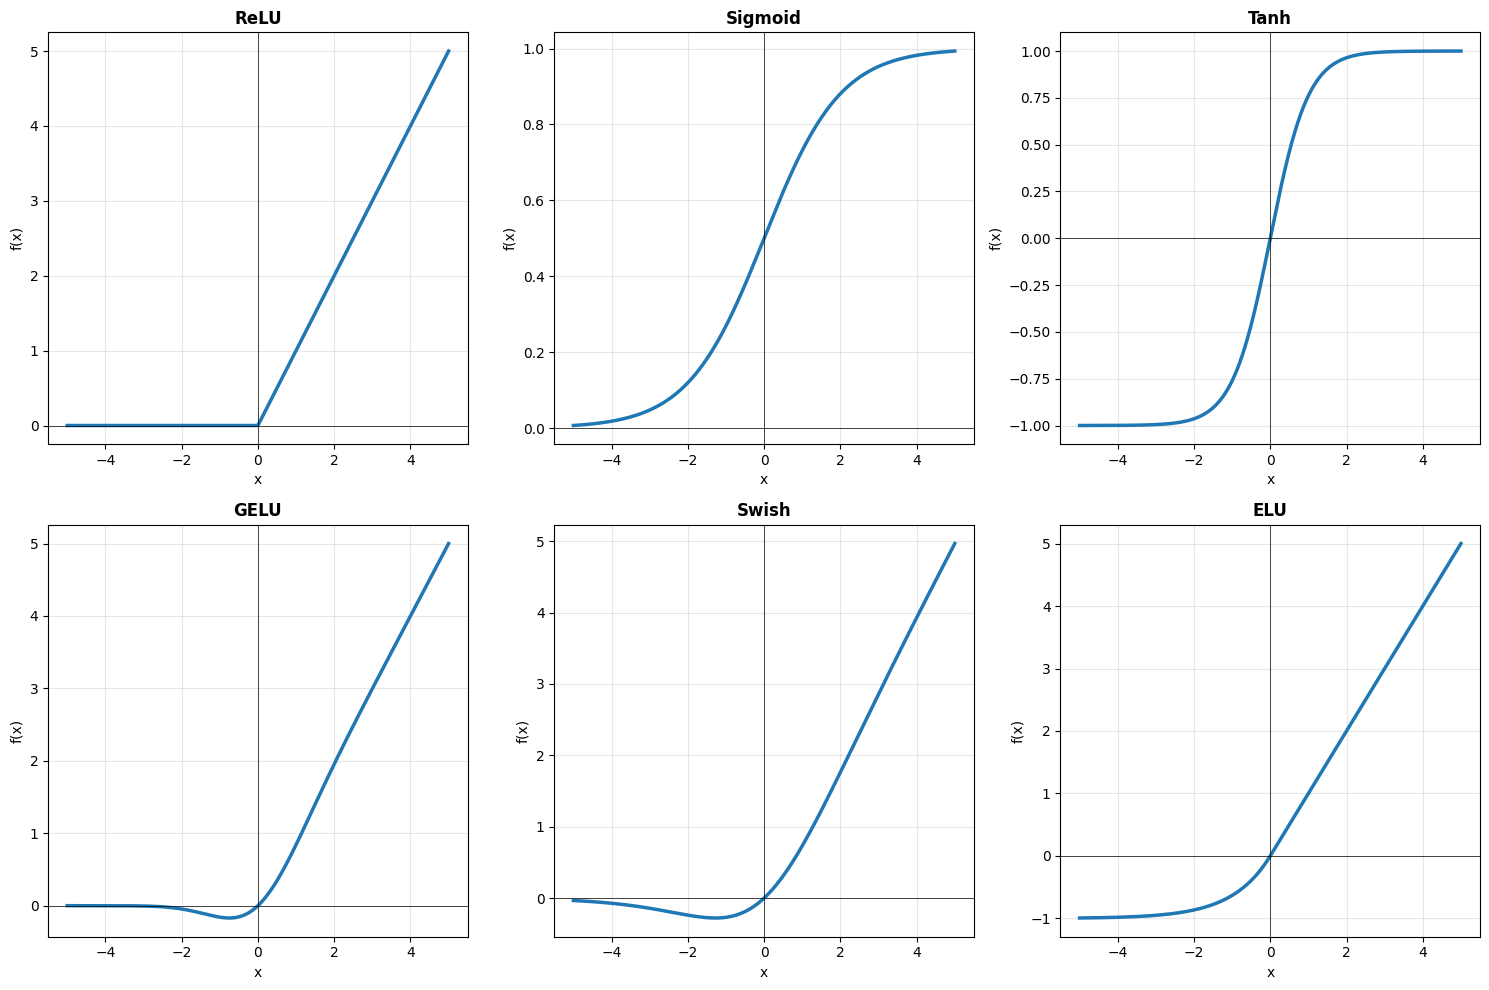

In [9]:
# Execute code with detailed step-by-step process
## 5. Visualization - Activation Functions

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

activations = [
    ('ReLU', y_relu),
    ('Sigmoid', y_sigmoid),
    ('Tanh', y_tanh),
    ('GELU', y_gelu),
    ('Swish', y_swish),
    ('ELU', y_elu)
]

# Iterate through batches of data
for idx, (name, y) in enumerate(activations):
    axes[idx].plot(x, y, linewidth=2.5)
    axes[idx].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[idx].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    axes[idx].grid(True, alpha=0.3)
# Update model parameters based on computed gradients
    axes[idx].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('f(x)')

plt.tight_layout()
plt.show()


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


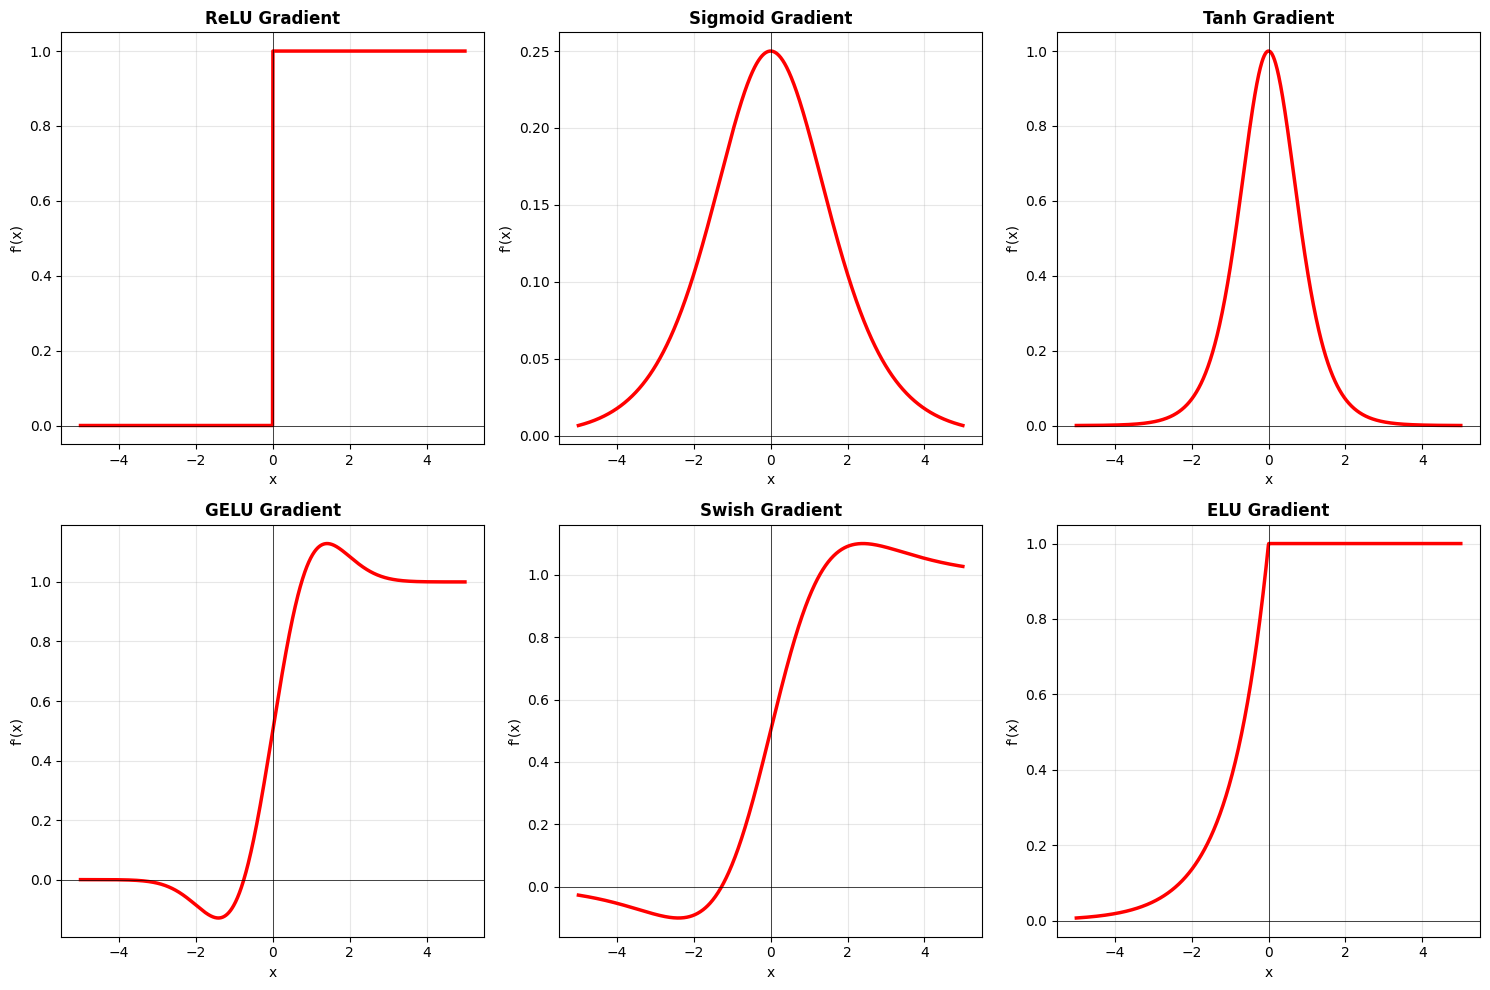

In [10]:
# Execute code with detailed step-by-step process
## 6. Visualization - Gradients

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

gradients = [
    ('ReLU', grad_relu),
    ('Sigmoid', grad_sigmoid),
    ('Tanh', grad_tanh),
    ('GELU', grad_gelu),
    ('Swish', grad_swish),
    ('ELU', grad_elu)
]

# Iterate through batches of data
for idx, (name, grad) in enumerate(gradients):
    axes[idx].plot(x, grad, linewidth=2.5, color='red')
    axes[idx].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[idx].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    axes[idx].grid(True, alpha=0.3)
# Update model parameters based on computed gradients
    axes[idx].set_title(f'{name} Gradient', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel("f'(x)")

plt.tight_layout()
plt.show()


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


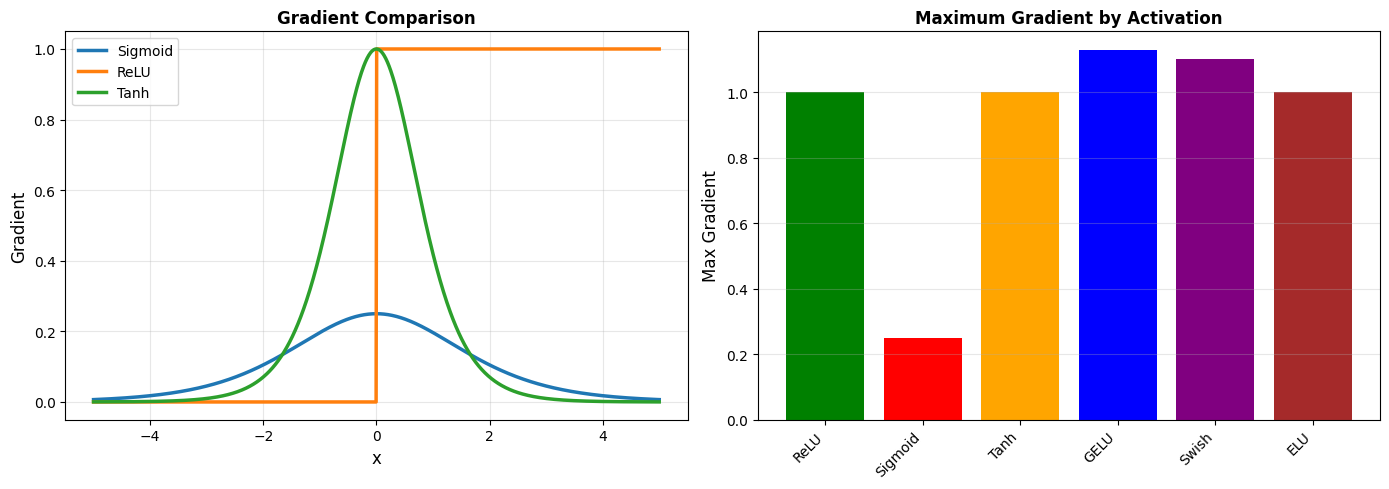


Gradient Analysis:
ReLU      : max gradient = 1.000000
Sigmoid   : max gradient = 0.249998
Tanh      : max gradient = 0.999975
GELU      : max gradient = 1.128903
Swish     : max gradient = 1.099839
ELU       : max gradient = 1.000000


In [11]:
# Execute code with detailed step-by-step process
## 7. Vanishing Gradient Problem

# Demonstrate vanishing gradients in sigmoid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Sigmoid gradient
ax1.plot(x, grad_sigmoid, linewidth=2.5, label='Sigmoid')
ax1.plot(x, grad_relu, linewidth=2.5, label='ReLU')
ax1.plot(x, grad_tanh, linewidth=2.5, label='Tanh')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel("Gradient", fontsize=12)
# Update model parameters based on computed gradients
ax1.set_title('Gradient Comparison', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gradient range
names = ['ReLU', 'Sigmoid', 'Tanh', 'GELU', 'Swish', 'ELU']
max_grads = [grad_relu.max(), grad_sigmoid.max(), grad_tanh.max(), 
              grad_gelu.max(), grad_swish.max(), grad_elu.max()]

ax2.bar(names, max_grads, color=['green', 'red', 'orange', 'blue', 'purple', 'brown'])
ax2.set_ylabel('Max Gradient', fontsize=12)
# Update model parameters based on computed gradients
ax2.set_title('Maximum Gradient by Activation', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nGradient Analysis:")
# Iterate through batches of data
for name, max_grad in zip(names, max_grads):
    print(f"{name:10s}: max gradient = {max_grad:.6f}")


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [12]:
# Define a custom function with detailed implementation
## 8. Using Activations in Networks

class NetworkWithActivations(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(10, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        
        # Select activation
        activation_dict = {
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh(),
            'gelu': nn.GELU(),
            'swish': nn.SiLU(),
            'elu': nn.ELU()
        }
        self.activation = activation_dict.get(activation, nn.ReLU())
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.activation(x)
        x = self.fc3(x)
        return x

# Test with different activations
x_test = torch.randn(4, 10)

# Iterate through batches of data
for act in ['relu', 'sigmoid', 'tanh', 'gelu']:
    model = NetworkWithActivations(activation=act)
    output = model(x_test)
    print(f"{act.upper():10s}: output shape {output.shape}, mean {output.mean().item():.4f}")


RELU      : output shape torch.Size([4, 2]), mean -0.0438
SIGMOID   : output shape torch.Size([4, 2]), mean 0.0589
TANH      : output shape torch.Size([4, 2]), mean -0.0030
GELU      : output shape torch.Size([4, 2]), mean 0.0928


## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [13]:
# Import necessary libraries for tensor operations and deep learning
## 9. Activation Function Properties

properties = {
    'ReLU': {
        'Dead neurons': 'Possible (negative outputs = 0)',
        'Computationally efficient': 'Yes',
        'Vanishing gradient': 'No',
# Iterate through batches of data
        'Non-saturating': 'Yes (for x > 0)',
        'Best for': 'Hidden layers, generally recommended'
    },
    'Sigmoid': {
        'Dead neurons': 'No',
        'Computationally efficient': 'Moderate',
        'Vanishing gradient': 'Yes (problematic)',
        'Non-saturating': 'No (saturates at 0 and 1)',
# Iterate through batches of data
        'Best for': 'Output layer for binary classification'
    },
    'Tanh': {
        'Dead neurons': 'No',
        'Computationally efficient': 'Moderate',
        'Vanishing gradient': 'Yes (less than sigmoid)',
        'Non-saturating': 'No (saturates at -1 and 1)',
        'Best for': 'RNNs, when zero-centered output is needed'
    },
    'GELU': {
        'Dead neurons': 'No',
        'Computationally efficient': 'Moderate',
        'Vanishing gradient': 'No',
        'Non-saturating': 'Yes',
        'Best for': 'Transformers (BERT, GPT, etc)'
    }
}

# Display as table
import pandas as pd

df = pd.DataFrame(properties).T
print(df.to_string())


                            Dead neurons Computationally efficient       Vanishing gradient              Non-saturating                                   Best for
ReLU     Possible (negative outputs = 0)                       Yes                       No             Yes (for x > 0)       Hidden layers, generally recommended
Sigmoid                               No                  Moderate        Yes (problematic)   No (saturates at 0 and 1)     Output layer for binary classification
Tanh                                  No                  Moderate  Yes (less than sigmoid)  No (saturates at -1 and 1)  RNNs, when zero-centered output is needed
GELU                                  No                  Moderate                       No                         Yes              Transformers (BERT, GPT, etc)


In [14]:
# Execute code with detailed step-by-step process
## 10. When to Use Which Activation

recommendations = {
# Iterate through batches of data
    'ReLU variants': 'Default choice for most networks',
    'LeakyReLU': 'If ReLU dying, negative slope helps',
# Iterate through batches of data
    'Sigmoid': 'Only for binary classification output',
    'Tanh': 'RNNs, LSTMs, older architectures',
    'GELU': 'Transformers, modern architectures',
    'Softmax': 'Multi-class classification output'
}

print("Activation Function Recommendations:")
print("=" * 50)
# Iterate through batches of data
for activation, use_case in recommendations.items():
    print(f"{activation:20s} -> {use_case}")

print("\n" + "=" * 50)
print("General Guidelines:")
# Iterate through batches of data
print("1. Start with ReLU for hidden layers")
print("2. Use Sigmoid for binary classification output")
print("3. Use Softmax for multi-class classification output")
print("4. Consider GELU for modern architectures")
print("5. Avoid Sigmoid/Tanh in hidden layers (vanishing gradients)")


Activation Function Recommendations:
ReLU variants        -> Default choice for most networks
LeakyReLU            -> If ReLU dying, negative slope helps
Sigmoid              -> Only for binary classification output
Tanh                 -> RNNs, LSTMs, older architectures
GELU                 -> Transformers, modern architectures
Softmax              -> Multi-class classification output

General Guidelines:
1. Start with ReLU for hidden layers
2. Use Sigmoid for binary classification output
3. Use Softmax for multi-class classification output
4. Consider GELU for modern architectures
5. Avoid Sigmoid/Tanh in hidden layers (vanishing gradients)


## Key Takeaways
# Iterate through batches of data
- ReLU is the default choice for hidden layers
- Sigmoid and Tanh suffer from vanishing gradients
- GELU is preferred in modern transformer architectures
- Activation choice affects gradient flow and training dynamics
- Different tasks may benefit from different activations

## References
- [Activation Functions Explained](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)
- [Understanding Vanishing Gradients](https://en.wikipedia.org/wiki/Vanishing_gradient_problem)
